### **1. Feature** **Scaling** **bold text**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df2 = df[['survived','pclass','age','parch']]
df2.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [ ]:
df2.isnull().sum()

,0
survived,0
pclass,0
age,177
parch,0


In [ ]:
df2['pclass'].mean()

np.float64(2.308641975308642)

In [ ]:
df2['age'].mean()

np.float64(29.69911764705882)

In [ ]:
df2.describe()

,survived,pclass,age,parch
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,0.381594
std,0.486592,0.836071,14.526497,0.806057
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,0.000000
50%,0.000000,3.000000,28.000000,0.000000
75%,1.000000,3.000000,38.000000,0.000000
max,1.000000,3.000000,80.000000,6.000000


In [ ]:
df_fill = df2.fillna(df2.mean())

In [ ]:
X = df_fill.drop('survived', axis = 1)
y = df_fill['survived']

In [ ]:
print('Shape of X = ', X.shape)
print('Shape of y = ', y.shape)

Shape of X =  (891, 3)
Shape of y =  (891,)


### **Train test**

In [ ]:
from  sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

In [ ]:
print('Shape of X_train = ', X_train.shape)
print('Shape of y_train = ', y_train.shape)
print('Shape of X_test = ', X_test.shape)
print('Shape of y_test = ', y_test.shape)

Shape of X_train =  (712, 3)
Shape of y_train =  (712,)
Shape of X_test =  (179, 3)
Shape of y_test =  (179,)


In [ ]:
sc = StandardScaler()
sc.fit(X_train)

StandardScaler()

In [ ]:
sc.mean_

array([ 2.30617978, 29.55409121,  0.39185393])

In [ ]:
sc.scale_

array([ 0.84405789, 12.99162985,  0.79647463])

In [ ]:
X_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.306180,29.554091,0.391854
std,0.844651,13.000763,0.797035
min,1.000000,0.420000,0.000000
25%,1.750000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,71.000000,5.000000


In [ ]:
sc.transform(X_train)

array([[ 0.8220055 , -0.42751304, -0.49198545],
       [ 0.8220055 ,  1.997125  , -0.49198545],
       [ 0.8220055 , -1.42815732, -0.49198545],
       ...,
       [ 0.8220055 ,  1.41983023,  3.27461284],
       [ 0.8220055 ,  0.01116307,  0.76354731],
       [ 0.8220055 , -0.08113618, -0.49198545]])

In [ ]:
X_train_sc = sc.transform(X_train)

In [ ]:
X_train_sc

array([[ 0.8220055 , -0.42751304, -0.49198545],
       [ 0.8220055 ,  1.997125  , -0.49198545],
       [ 0.8220055 , -1.42815732, -0.49198545],
       ...,
       [ 0.8220055 ,  1.41983023,  3.27461284],
       [ 0.8220055 ,  0.01116307,  0.76354731],
       [ 0.8220055 , -0.08113618, -0.49198545]])

In [ ]:
sc.transform(X_test)

array([[-1.54750023,  0.80404914, -0.49198545],
       [ 0.8220055 ,  0.18826805, -0.49198545],
       [ 0.8220055 ,  0.03432278, -0.49198545],
       [-1.54750023,  0.01116307, -0.49198545],
       [-0.36274737,  0.34221332,  0.76354731],
       [ 0.8220055 ,  0.18826805, -0.49198545],
       [-1.54750023,  1.34285759, -0.49198545],
       [ 0.8220055 , -1.04329413, -0.49198545],
       [-0.36274737,  2.80533768, -0.49198545],
       [-1.54750023, -1.12026677,  0.76354731],
       [-0.36274737,  0.11129541, -0.49198545],
       [-0.36274737, -0.1196225 , -0.49198545],
       [-1.54750023,  1.18891232, -0.49198545],
       [ 0.8220055 , -0.50448568, -0.49198545],
       [ 0.8220055 ,  0.88102177,  5.78567837],
       [-0.36274737, -0.35054041, -0.49198545],
       [-0.36274737,  0.49615859,  2.01908008],
       [ 0.8220055 ,  0.01116307, -0.49198545],
       [ 0.8220055 ,  0.01116307, -0.49198545],
       [-0.36274737, -0.81237622, -0.49198545],
       [ 0.8220055 ,  0.01116307, -0.491

In [ ]:
X_train

,pclass,age,parch
770,3,24.000000,0
152,3,55.500000,0
731,3,11.000000,0
775,3,18.000000,0
324,3,29.699118,2
...,...,...,...
528,3,39.000000,0
709,3,29.699118,1
736,3,48.000000,3
485,3,29.699118,1


In [ ]:
X_train_sc = pd.DataFrame(X_train_sc, columns=['pclass',
                                               'age',
                                               'parch'])

In [ ]:
X_train_sc

,pclass,age,parch
0,0.822005,-0.427513,-0.491985
1,0.822005,1.997125,-0.491985
2,0.822005,-1.428157,-0.491985
3,0.822005,-0.889349,-0.491985
4,0.822005,0.011163,2.019080
...,...,...,...
707,0.822005,0.727077,-0.491985
708,0.822005,0.011163,0.763547
709,0.822005,1.419830,3.274613
710,0.822005,0.011163,0.763547


In [ ]:
X_test_sc = pd.DataFrame(X_test_sc, columns=['pclass',
                                               'age',
                                               'parch'])

In [ ]:
X_test_sc

,pclass,age,parch
0,-1.547500,0.804049,-0.491985
1,0.822005,0.188268,-0.491985
2,0.822005,0.034323,-0.491985
3,-1.547500,0.011163,-0.491985
4,-0.362747,0.342213,0.763547
...,...,...,...
174,0.822005,0.011163,2.019080
175,0.822005,-0.273568,-0.491985
176,-0.362747,-0.427513,-0.491985
177,-1.547500,0.111295,-0.491985


In [ ]:
X_train_sc.describe()

,pclass,age,parch
count,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.160121e-16,1.521879e-16,6.237208e-17
std,1.000703e+00,1.000703e+00,1.000703e+00
min,-1.547500e+00,-2.242528e+00,-4.919855e-01
25%,-6.589356e-01,-5.814583e-01,-4.919855e-01
50%,8.220055e-01,1.116307e-02,-4.919855e-01
75%,8.220055e-01,4.191860e-01,-4.919855e-01
max,8.220055e-01,3.190201e+00,5.785678e+00


In [ ]:
X_train_sc.describe().round(2)

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.55,-2.24,-0.49
25%,-0.66,-0.58,-0.49
50%,0.82,0.01,-0.49
75%,0.82,0.42,-0.49
max,0.82,3.19,5.79


### **MinMaxScaler**

In [ ]:
mnc = MinMaxScaler()

In [ ]:
mnc.fit(X_train)

MinMaxScaler()

In [ ]:
X_train_mnc = mnc.transform(X_train)

In [ ]:
X_train_mnc

array([[1.        , 0.33408898, 0.        ],
       [1.        , 0.78039105, 0.        ],
       [1.        , 0.14990082, 0.        ],
       ...,
       [1.        , 0.67412865, 0.6       ],
       [1.        , 0.4148359 , 0.2       ],
       [1.        , 0.39784642, 0.        ]])

In [ ]:
X_test_mnc = mnc.transform(X_test)

In [ ]:
X_test_mnc

array([[0.        , 0.56078209, 0.        ],
       [1.        , 0.44743553, 0.        ],
       [1.        , 0.41909889, 0.        ],
       [0.        , 0.4148359 , 0.        ],
       [0.5       , 0.47577217, 0.2       ],
       [1.        , 0.44743553, 0.        ],
       [0.        , 0.65996033, 0.        ],
       [1.        , 0.22074242, 0.        ],
       [0.5       , 0.9291584 , 0.        ],
       [0.        , 0.2065741 , 0.2       ],
       [0.5       , 0.43326721, 0.        ],
       [0.5       , 0.39076226, 0.        ],
       [0.        , 0.63162369, 0.        ],
       [1.        , 0.31992066, 0.        ],
       [1.        , 0.57495041, 1.        ],
       [0.5       , 0.3482573 , 0.        ],
       [0.5       , 0.50410881, 0.4       ],
       [1.        , 0.4148359 , 0.        ],
       [1.        , 0.4148359 , 0.        ],
       [0.5       , 0.26324738, 0.        ],
       [1.        , 0.4148359 , 0.        ],
       [0.5       , 0.24907906, 0.        ],
       [1.

In [ ]:
X_train_mnc = pd.DataFrame(X_train_mnc, columns=['pclass',
                                               'age',
                                               'parch'])

In [ ]:
X_train_mnc

,pclass,age,parch
0,0.0,0.560782,0.0
1,1.0,0.447436,0.0
2,1.0,0.419099,0.0
3,0.0,0.414836,0.0
4,0.5,0.475772,0.2
...,...,...,...
174,1.0,0.414836,0.4
175,1.0,0.362426,0.0
176,0.5,0.334089,0.0
177,0.0,0.433267,0.0


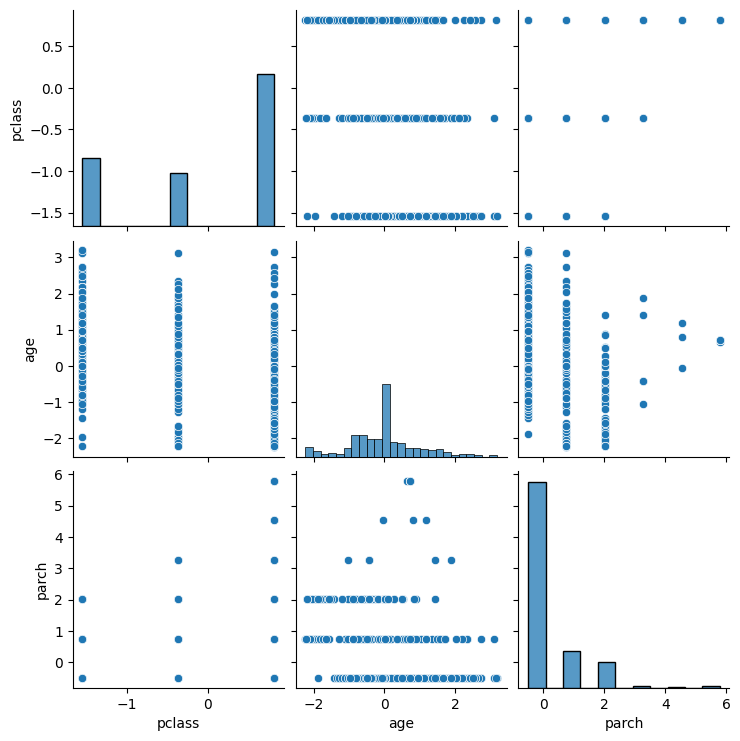

In [ ]:
sns.pairplot(X_train_sc)

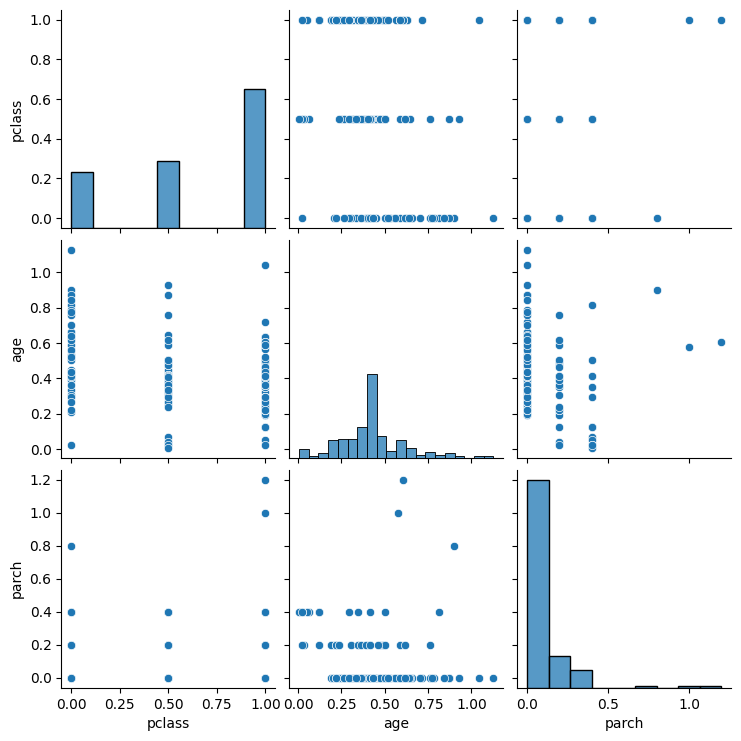

In [ ]:
sns.pairplot(X_train_mnc)

### **Types of Feature Scaling**